In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
import kagglehub
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np


In [11]:
from PIL import Image, ImageEnhance
import numpy as np
import random

# Funkcja augmentacji
def augment_image(img):
    # Obrót ±15 stopni
    angle = random.uniform(-15, 15)
    img = img.rotate(angle)

    # Odbicie lustrzane
    if random.random() > 0.5:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)

    # Jasność
    enhancer = ImageEnhance.Brightness(img)
    img = enhancer.enhance(random.uniform(0.8, 1.2))

    # Kontrast
    enhancer = ImageEnhance.Contrast(img)
    img = enhancer.enhance(random.uniform(0.8, 1.2))

    return img

In [2]:
path = kagglehub.dataset_download("nikolasgegenava/cat-breeds")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Cezary\.cache\kagglehub\datasets\nikolasgegenava\cat-breeds\versions\1


In [ ]:
IMG_SIZE = (64, 64)

X = []
y = []

for _, row in df.iterrows():
    img = Image.open(row["image_path"]).convert("RGB")
    img = img.resize(IMG_SIZE)

    img_array = np.array(img)
    X.append(img_array.flatten())

    y.append(row["breed"])

X = np.array(X)
y = np.array(y)


In [3]:
image_paths = []
labels = []
img_path = path + '\\cat-breeds\\cat-breeds'

for breed in os.listdir(img_path):
    breed_path = os.path.join(img_path, breed)
    if os.path.isdir(breed_path):
        for img in os.listdir(breed_path):
            image_paths.append(os.path.join(breed_path, img))
            labels.append(breed)

df = pd.DataFrame({
    "image_path": image_paths,
    "breed": labels
})

print(df.head())
print("Liczba obrazów:", len(df))

                                          image_path       breed
0  C:\Users\Cezary\.cache\kagglehub\datasets\niko...  abyssinian
1  C:\Users\Cezary\.cache\kagglehub\datasets\niko...  abyssinian
2  C:\Users\Cezary\.cache\kagglehub\datasets\niko...  abyssinian
3  C:\Users\Cezary\.cache\kagglehub\datasets\niko...  abyssinian
4  C:\Users\Cezary\.cache\kagglehub\datasets\niko...  abyssinian
Liczba obrazów: 11284


breed
abyssinian              200
chausie                 200
cyprus                  200
donskoy                 200
european_shorthair      200
                       ... 
laperm                  120
sphynx                  120
chartreux               114
russian_blue            109
norwegian_forest_cat     97
Name: count, Length: 66, dtype: int64


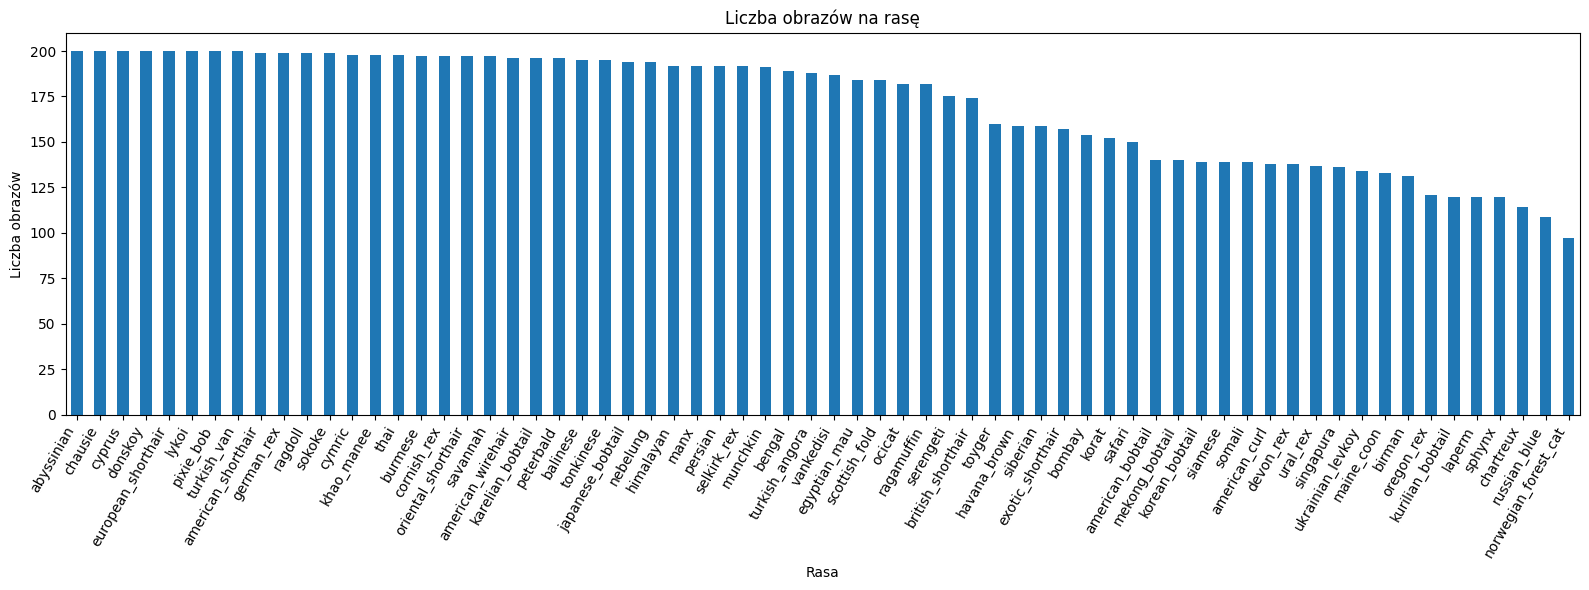

In [22]:
breed_counts = df["breed"].value_counts()
print(breed_counts)
plt.figure(figsize=(16,6)) 
breed_counts.plot(kind="bar")

plt.title("Liczba obrazów na rasę")
plt.xlabel("Rasa")
plt.ylabel("Liczba obrazów")

plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
from pathlib import Path

widths = []
heights = []
extensions = []

for path_img in df["image_path"]:
    with Image.open(path_img) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)

    extensions.append(Path(path_img).suffix.lower())

# statystyki rozdzielczości
print("Szerokość:")
print("średnia:", np.mean(widths))
print("mediana:", np.median(widths))
print("min:", np.min(widths))
print("max:", np.max(widths))

print("\nWysokość:")
print("średnia:", np.mean(heights))
print("mediana:", np.median(heights))
print("min:", np.min(heights))
print("max:", np.max(heights))

# rozszerzenia plików
ext_counts = Counter(extensions)

print("\nRozszerzenia plików:")
for ext, count in ext_counts.items():
    print(ext, ":", count)

Szerokość:
średnia: 147.62531017369727
mediana: 162.0
min: 44
max: 300

Wysokość:
średnia: 117.11006735200283
mediana: 116.0
min: 34
max: 140

Rozszerzenia plików:
.jpg : 11276
.png : 8


In [25]:
width_mode = Counter(widths).most_common(1)[0]
height_mode = Counter(heights).most_common(1)[0]

print("Moda szerokości:", width_mode)
print("Moda wysokości:", height_mode)

Moda szerokości: (162, 7310)
Moda wysokości: (140, 3969)


In [4]:
import numpy as np
from PIL import Image
from sklearn.preprocessing import LabelEncoder

IMG_SIZE = (162, 140)

X = []
y = []

for _, row in df.iterrows():
    img = Image.open(row["image_path"]).convert("RGB")
    img = img.resize(IMG_SIZE)

    img_array = np.array(img)
    X.append(img_array.flatten())

    y.append(row["breed"])

X = np.array(X)
y = np.array(y)

print("Shape X:", X.shape)   # (liczba_obrazów, 12288)

c:\Users\Cezary\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\PIL\Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Shape X: (11284, 68040)


In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Explained variance: [0.42293189 0.06330193 0.04133203 0.03355984 0.02852404 0.02513914
 0.01587591 0.01496729 0.01287341 0.0124598  0.01063242 0.00874056
 0.00730974 0.00674105 0.00607215 0.00574347 0.00566593 0.00528921
 0.0051141  0.00485877 0.00454022 0.00414172 0.00402311 0.00353437
 0.0034492  0.00338418 0.00313614 0.00298965 0.00290225 0.00269779
 0.00263388 0.00259158 0.00243964 0.00240788 0.0022946  0.00226889
 0.00209091 0.00196586 0.00191008 0.00188598 0.00179614 0.00175028
 0.00172637 0.00164768 0.00163115 0.001614   0.00156981 0.00153654
 0.00150354 0.00147217 0.00140403 0.00137118 0.00132896 0.00130649
 0.00123368 0.00120131 0.00116236 0.00114992 0.00113829 0.00111819
 0.00110127 0.00107019 0.00106609 0.00103441 0.00102151 0.00101766
 0.00098306 0.00097485 0.00094913 0.00093414 0.00091231 0.0008954
 0.00086423 0.000853   0.00084109 0.00082109 0.00081369 0.00079569
 0.00078966 0.0007841  0.00076538 0.00075535 0.00074095 0.00073015
 0.00072442 0.00071762 0.00071292 0.0007083

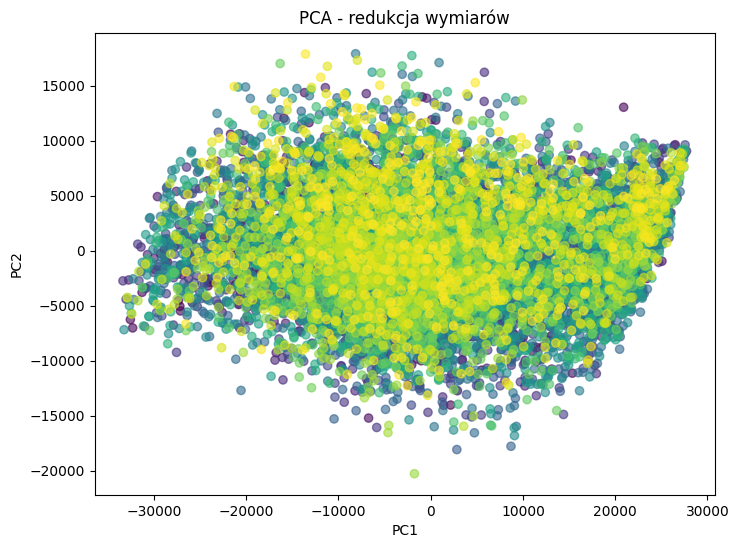

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=100)
X_pca = pca.fit_transform(X)

# print("Explained variance:", pca.explained_variance_ratio_)

# plt.figure(figsize=(8,6))
# plt.scatter(X_pca[:,0], X_pca[:,1], c=LabelEncoder().fit_transform(y), alpha=0.6)
# plt.title("PCA - redukcja wymiarów")
# plt.xlabel("PC1")
# plt.ylabel("PC2")
# plt.show()

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

le = LabelEncoder()
y_encoded = le.fit_transform(y)

n_classes = len(np.unique(y_encoded))
n_components = n_classes - 1

lda = LinearDiscriminantAnalysis(n_components=n_components)
X_lda = lda.fit_transform(X, y_encoded)

# plt.figure(figsize=(8,6))
# plt.scatter(X_lda[:,0], X_lda[:,1], c=y_encoded, alpha=0.6)
# plt.title("LDA - redukcja wymiarów")
# plt.xlabel("LD1")
# plt.ylabel("LD2")
# plt.show()

In [ ]:
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

le = LabelEncoder()
y_encoded = le.fit_transform(y)
n_classes = len(np.unique(y_encoded))

# 1. Podział danych
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

# 2. Lista klasyfikatorów
classifiers = {
    "SVM": SVC(kernel="rbf"),
    "Decision Tree": DecisionTreeClassifier(max_depth=10),
    "XGBoost": XGBClassifier(objective="multi:softmax", 
                              num_class=n_classes,
                              eval_metric="mlogloss")
}

# 3. Redukcje wymiarów
reducers = {
    "PCA": PCA(n_components=50),
    "LDA": LinearDiscriminantAnalysis(n_components=n_classes-1) 
}

# 4. Porównanie wyników
results = []

for red_name, reducer in reducers.items():
    for clf_name, clf in classifiers.items():
        print(f"Trening: {red_name} + {clf_name}")

        # Pipeline: standaryzacja + redukcja + klasyfikator
        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("reducer", reducer),
            ("clf", clf)
        ])
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        results.append({
            "Reduction": red_name,
            "Classifier": clf_name,
            "Accuracy": acc
        })
        print(f"Accuracy: {acc:.4f}\n")

# 5. Tabela porównawcza
df_results = pd.DataFrame(results)
print(df_results.pivot(index="Reduction", columns="Classifier", values="Accuracy"))

Trening: PCA + SVM
Accuracy: 0.1006

Trening: PCA + Decision Tree
Accuracy: 0.0523

Trening: PCA + XGBoost
Accuracy: 0.0930

Trening: LDA + SVM
Accuracy: 0.0155

Trening: LDA + Decision Tree


In [5]:
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np

# Kod przygotowujący dane
le = LabelEncoder()
y_encoded = le.fit_transform(y)
n_classes = len(np.unique(y_encoded))

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

# Standaryzacja
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Redukcje wymiarów
reducers = {
    "PCA": PCA(n_components=50),
    "LDA": LinearDiscriminantAnalysis(n_components=int(n_classes / 2))
}

X_train_reduced = {}
X_test_reduced = {}

for red_name, reducer in reducers.items():
    print(f"Redukcja wymiarów: {red_name}")
    X_train_reduced[red_name] = reducer.fit_transform(X_train_scaled, y_train if red_name=="LDA" else None)
    X_test_reduced[red_name] = reducer.transform(X_test_scaled)

# Klasyfikatory
classifiers = {
    "SVM": SVC(kernel="rbf"),
    "Decision Tree": DecisionTreeClassifier(max_depth=10),
    "XGBoost": XGBClassifier(objective="multi:softmax", num_class=n_classes, eval_metric="mlogloss")
}

# Trenowanie wszystkich klasyfikatorów na zredukowanych danych
results = []

for red_name in reducers.keys():
    X_tr = X_train_reduced[red_name]
    X_te = X_test_reduced[red_name]
    
    for clf_name, clf in classifiers.items():
        print(f"Trening: {red_name} + {clf_name}")
        clf.fit(X_tr, y_train)
        y_pred = clf.predict(X_te)
        acc = accuracy_score(y_test, y_pred)
        results.append({
            "Reduction": red_name,
            "Classifier": clf_name,
            "Accuracy": acc
        })
        print(f"Accuracy: {acc:.4f}\n")

# Porównanie wyników
df_results = pd.DataFrame(results)
print(df_results.pivot(index="Reduction", columns="Classifier", values="Accuracy"))

Redukcja wymiarów: PCA
Redukcja wymiarów: LDA
Trening: PCA + SVM
Accuracy: 0.1001

Trening: PCA + Decision Tree
Accuracy: 0.0470

Trening: PCA + XGBoost
Accuracy: 0.0873

Trening: LDA + SVM
Accuracy: 0.0142

Trening: LDA + Decision Tree
Accuracy: 0.0168

Trening: LDA + XGBoost
Accuracy: 0.0160

Classifier  Decision Tree       SVM   XGBoost
Reduction                                    
LDA              0.016837  0.014178  0.015950
PCA              0.046965  0.100133  0.087284


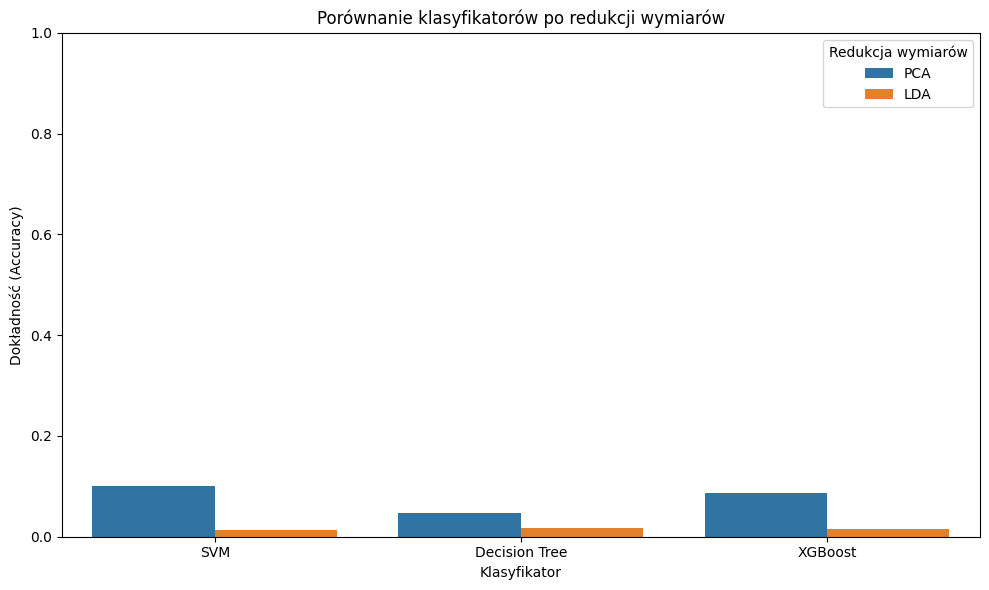

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Przygotowanie danych do wykresu
df_plot = df_results.copy()
plt.figure(figsize=(10,6))

sns.barplot(
    data=df_plot,
    x="Classifier",
    y="Accuracy",
    hue="Reduction"
)

plt.title("Porównanie klasyfikatorów po redukcji wymiarów")
plt.ylim(0,1)
plt.ylabel("Dokładność (Accuracy)")
plt.xlabel("Klasyfikator")
plt.legend(title="Redukcja wymiarów")
plt.tight_layout()
plt.show()

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=2137
)

In [18]:
n_augments = 2

# Nowe zbiory
X_train_aug = []
y_train_aug = []

for i in range(len(X_train)):
    # Oryginał
    X_train_aug.append(X_train[i])
    y_train_aug.append(y_train[i])
    
    # Zamiana z powrotem na PIL Image, żeby augmentować
    img = Image.fromarray(X_train[i].reshape(IMG_SIZE[1], IMG_SIZE[0], 3))
    
    for _ in range(n_augments):
        img_aug = augment_image(img)
        X_train_aug.append(np.array(img_aug).flatten())
        y_train_aug.append(y_train[i])

# Zamiana na numpy array
X_train_aug = np.array(X_train_aug)
y_train_aug = np.array(y_train_aug)

print("Rozmiar treningowego po augmentacji:", X_train_aug.shape)
print("Rozmiar testowego (bez augmentacji):", X_test.shape)

X_train = X_train_aug
y_train = y_train_aug


Rozmiar treningowego po augmentacji: (54162, 12288)
Rozmiar testowego (bez augmentacji): (2257, 12288)


In [ ]:

# Kod przygotowujący dane
le = LabelEncoder()
y_encoded = le.fit_transform(y)
n_classes = len(np.unique(y_encoded))

# Standaryzacja
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Redukcje wymiarów
reducers = {
    "PCA": PCA(n_components=100),
    # "LDA": LinearDiscriminantAnalysis(n_components=30)
}

X_train_reduced = {}
X_test_reduced = {}

for red_name, reducer in reducers.items():
    print(f"Redukcja wymiarów: {red_name}")
    X_train_reduced[red_name] = reducer.fit_transform(X_train_scaled, y_train if red_name=="LDA" else None)
    X_test_reduced[red_name] = reducer.transform(X_test_scaled)

# Klasyfikatory
classifiers = {
    "SVM": SVC(kernel="rbf"),
    "Decision Tree": DecisionTreeClassifier(max_depth=10),
    "XGBoost": XGBClassifier(objective="multi:softmax", num_class=n_classes, eval_metric="mlogloss")
}

# Trenowanie wszystkich klasyfikatorów na zredukowanych danych
results = []

for red_name in reducers.keys():
    X_tr = X_train_reduced[red_name]
    X_te = X_test_reduced[red_name]
    
    for clf_name, clf in classifiers.items():
        print(f"Trening: {red_name} + {clf_name}")
        
        # Trenowanie
        clf.fit(X_tr, y_train)
        
        # Predykcja
        y_pred_train = clf.predict(X_tr)
        y_pred_test = clf.predict(X_te)
        
        # Dokładności
        acc_train = accuracy_score(y_train, y_pred_train)
        acc_test = accuracy_score(y_test, y_pred_test)
        
        results.append({
            "Reduction": red_name,
            "Classifier": clf_name,
            "Train_Accuracy": acc_train,
            "Test_Accuracy": acc_test
        })
        
        print(f"Train Accuracy: {acc_train:.4f}, Test Accuracy: {acc_test:.4f}\n")

# Porównanie wyników
df_results = pd.DataFrame(results)
print(df_results.pivot(index="Reduction", columns="Classifier", values="Test_Accuracy"))

Redukcja wymiarów: PCA
Trening: PCA + SVM
Train Accuracy: 0.4735, Test Accuracy: 0.1156

Trening: PCA + Decision Tree
Train Accuracy: 0.1301, Test Accuracy: 0.0647

Trening: PCA + XGBoost
Train Accuracy: 0.9994, Test Accuracy: 0.0784



KeyError: 'Accuracy'